# L5. Lab: Your On-Device Assistant

A day of photos, a voice note, and text notes land in one `EdgeShard` — the kind of day a phone or a pair of smart glasses captures. You build the recall yourself, then ask it your own questions and add your own memories, all offline.

## 1. A day's captures

In [1]:
import json
from helper import transcribe

memories = json.load(open("../data/memories.json"))
kinds = {}
for m in memories:
    kinds[m["source_type"]] = kinds.get(m["source_type"], 0) + 1
print(len(memories), "captures:",
      ", ".join(f"{v} {k}" for k, v in sorted(kinds.items())))

for m in memories:
    if m["source_type"] == "voice":
        m["transcript"] = transcribe(f"../data/audio/{m['audio_file']}")

voice = [m for m in memories if m["source_type"] == "voice"]
print("\nA voice note, transcribed on-device:")
print(" ", voice[0]["transcript"])

42 captures: 17 photo, 20 text, 5 voice



A voice note, transcribed on-device:
  Note to self, the ramen downtown was incredible, $14 and worth it. Sat right by the window.


## 2. The day at a glance

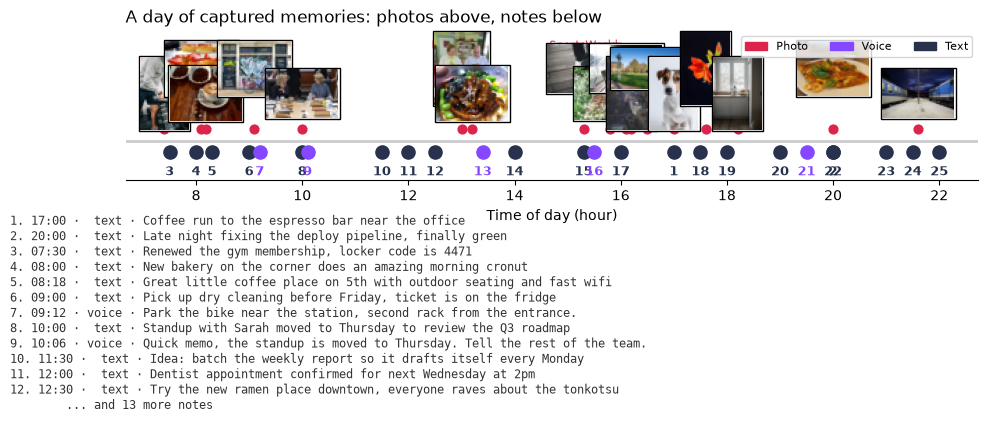

In [2]:
from helper import day_timeline
day_timeline(memories, "../data/images")

## 3. One shard, two named vectors

In [3]:
import shutil
from pathlib import Path
from qdrant_edge import EdgeShard, EdgeConfig, EdgeVectorParams, Distance

SHARD_DIR = "./day_shard"
shutil.rmtree(SHARD_DIR, ignore_errors=True)
Path(SHARD_DIR).mkdir(parents=True, exist_ok=True)

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
shard = EdgeShard.create(SHARD_DIR, config)

In [4]:
from qdrant_edge import UpdateOperation, PayloadSchemaType

for field, kind in [
    ("category", PayloadSchemaType.Keyword),
    ("location", PayloadSchemaType.Keyword),
    ("timestamp", PayloadSchemaType.Float),
    ("price", PayloadSchemaType.Float),
]:
    shard.update(UpdateOperation.create_field_index(field, kind))
print("Shard ready: text + image vectors, 4 indexed fields")

Shard ready: text + image vectors, 4 indexed fields


## 4. Store the day

In [5]:
from qdrant_edge import Point
from helper import embed_text, embed_image

texts = [m for m in memories if m["source_type"] in ("text", "voice")]
photos = [m for m in memories if m["source_type"] == "photo"]

note = texts[0]
doc = note.get("note") or note["transcript"]
shard.update(UpdateOperation.upsert_points([
    Point(id=note["id"], vector={"text": embed_text([doc])[0]}, payload=note),
]))
print("Stored 1 text memory by hand:", doc[:40])

Stored 1 text memory by hand: Great little coffee place on 5th with ou


In [6]:
photo = photos[0]
image_vector = embed_image([f"../data/images/{photo['file']}"])[0]
shard.update(UpdateOperation.upsert_points([
    Point(id=photo["id"], vector={"image": image_vector}, payload=photo),
]))
print("Stored 1 photo by hand:", photo["file"])

Stored 1 photo by hand: coffee.jpg


In [7]:
rest_texts = texts[1:]
rest_photos = photos[1:]

text_vectors = embed_text([m.get("note") or m["transcript"] for m in rest_texts])
shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"text": text_vectors[i]}, payload=m)
    for i, m in enumerate(rest_texts)
]))

image_vectors = embed_image([f"../data/images/{m['file']}" for m in rest_photos])
shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"image": image_vectors[i]}, payload=m)
    for i, m in enumerate(rest_photos)
]))
shard.optimize()
print("Total memories:", shard.info().points_count)

Total memories: 42


## 5. Inspect a stored point

In [8]:
from qdrant_edge import ScrollRequest

records, _ = shard.scroll(
    ScrollRequest(limit=1, with_payload=True, with_vector=True)
)
p = records[0]
print("id:", p.id)
print("named vectors:", list(p.vector.keys()))
print("payload:", p.payload)

id: 0
named vectors: ['text']
payload: {'id': 0, 'source_type': 'text', 'category': 'food', 'location': '5th St', 'timestamp': 1699949880, 'note': 'Great little coffee place on 5th with outdoor seating and fast wifi'}


## 6. How recall works

In [9]:
from qdrant_edge import Query, QueryRequest
from helper import embed_query, embed_query_clip


def recall(question, query_filter=None, limit=3):
    text_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(embed_query(question), using="text"),
            filter=query_filter,
            limit=limit,
            with_payload=True,
        )
    )
    image_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(embed_query_clip(question), using="image"),
            filter=query_filter,
            limit=limit,
            with_payload=True,
        )
    )
    return {
        "Photos": image_hits,
        "Voice Notes": [h for h in text_hits
                        if h.payload.get("source_type") == "voice"],
        "Text Notes": [h for h in text_hits
                       if h.payload.get("source_type") == "text"],
    }


def show_raw(hits):
    for space, rows in hits.items():
        for h in rows:
            p = h.payload
            label = (p.get("store") or p.get("note")
                     or p.get("transcript") or p.get("file", ""))[:34]
            print(f"{space:11} {h.score:.3f} id={h.id}  {label}")


print("recall(question, filter) -> hits by modality")

recall(question, filter) -> hits by modality


## 7. The payoff: "black and white sneakers under $50"

Photos      0.252 id=30  SportsWorld
Photos      0.171 id=38  book.jpg
Text Notes  0.652 id=5  Liked the black and white running 



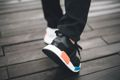
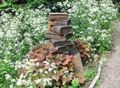

In [10]:
from qdrant_edge import Filter, FieldCondition, MatchValue, RangeFloat
from helper import memory_inbox

shopping = Filter(
    must=[
        FieldCondition(key="category", match=MatchValue(value="shopping")),
        FieldCondition(key="price", range=RangeFloat(lt=50)),
    ]
)
hits = recall("black and white sneakers", shopping)
show_raw(hits)
memory_inbox(hits, "../data/images")

## 8. Your turn: ask a question

Photos      0.270 id=25  Blue Cup
Photos      0.239 id=31  bicycle.jpg
Photos      0.216 id=36  kitchen.jpg
Text Notes  0.690 id=0  Great little coffee place on 5th w
Text Notes  0.636 id=18  Coffee run to the espresso bar nea
Text Notes  0.571 id=11  Found a quiet cafe with good wifi 



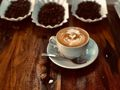
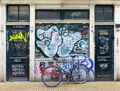
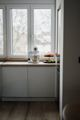

In [11]:
# Change my_question and re-run; set my_category = None for everything.
# Try: "where did I park the bike", "gym locker code", "when is the dentist".
my_question = "good coffee nearby"
my_category = None

my_filter = (
    Filter(must=[FieldCondition(key="category",
                                match=MatchValue(value=my_category))])
    if my_category else None
)
hits = recall(my_question, my_filter)
show_raw(hits)
memory_inbox(hits, "../data/images")

## 9. The payoff: add your own memory, then recall it

Photos      0.213 id=31  bicycle.jpg
Photos      0.198 id=33  street.jpg
Photos      0.186 id=39  laptop.jpg
Voice Notes 0.475 id=23  Park the bike near the station, se
Voice Notes 0.468 id=24  Just remember, we are low on coffe
Text Notes  0.757 id=900  Left the spare key with the neighb



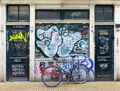
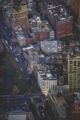
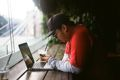

In [12]:
# Add your own text memory, then recall it. Change this!
my_note = "Left the spare key with the neighbor in apartment 4B"
my_payload = {
    "id": 900, "source_type": "text", "category": "home",
    "location": "Home", "timestamp": 1_699_920_000 + 18 * 3600,
}
shard.update(UpdateOperation.upsert_points([
    Point(id=900, vector={"text": embed_text([my_note])[0]},
          payload={**my_payload, "note": my_note}),
]))
shard.optimize()

hits = recall("where did I leave the spare key")
show_raw(hits)
memory_inbox(hits, "../data/images")

## 10. The payoff: forget a memory

Photos      0.171 id=38  book.jpg
Text Notes  0.652 id=5  Liked the black and white running 



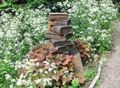

In [13]:
# Memory forgets, too. Delete the sneakers photo by id, then
# run the very same recall from section 7.
sneakers_id = next(m["id"] for m in photos if m["file"] == "sneakers.jpg")
shard.update(UpdateOperation.delete_points([sneakers_id]))
shard.optimize()

hits = recall("black and white sneakers", shopping)
show_raw(hits)
memory_inbox(hits, "../data/images")

In [15]:
from helper import cleanup
cleanup(shard, "./day_shard")
print("Cleaned up")

Cleaned up
